# De novo assembly of scRNA-seq reads from TCR/BCR genes 🧬


### BMGLab Bioinformatics Workshop - 02.07.2026 - İzmir

##### *Prepared and adapted by BMGLab Students*
---






Assessing the immunological profile of T and B cells within the tumor microenvironment (TME) constitutes a fundamental analytical step in comprehending tumor-immune system interactions. This assessment necessitates the calculation of receptor diversity and clonality metrics for tumor-infiltrating lymphocytes. The activation of T and B cells is mediated by the recognition and binding of their respective receptors—T cell receptors (TCRs) and B cell receptors (BCRs)—to tumor-associated antigens. The capacity of TCRs and BCRs to recognize a broad spectrum of antigens relies on high structural diversity, generated through V(D)J recombination, a mechanism that rearranges V, D, and J genomic segments.

### The CDR3 and Immune Repertoire Profiling
The complementarity-determining region 3 (CDR3), centrally located within the antigen-binding site of TCRs and BCRs, represents the most hypervariable segment of these receptors. The assembly of the V(D)J junctional sequence is the primary source of TCR/BCR CDR3 diversity. Immune repertoire profiling, which encompasses the sequencing and characterization of CDR3 sequences from TCRs and BCRs within a tumor sample, is essential for quantifying the diversity, clonality, and dynamic evolution of T and B cell populations. These metrics function as critical biomarkers for evaluating immunotherapy responses.

*TRUST4, open-source algorithm for reconstruction of immune receptor repertoires in αβ/γδ T cells and B cells from RNA-sequencing (RNA-seq) data.*

> Song, L., Cohen, D., Ouyang, Z. et al. TRUST4: immune repertoire reconstruction from bulk and single-cell RNA-seq data. Nat Methods (2021). https://doi.org/10.1038/s41592-021-01142-2


## What is SRA Toolkit?

The **SRA Toolkit** is a collection of tools developed by NCBI (National Center for Biotechnology Information) to access and convert data stored in the **Sequence Read Archive (SRA)**.


Key tools used in this tutorial:

| Tool | Purpose |
|------|---------|
| `prefetch` | Downloads SRA data files (`.sra`) locally |
| `fasterq-dump` | Converts `.sra` files to FASTQ format (faster than `fastq-dump`) |
| `fastq-dump` | Legacy converter (slower, not recommended) |

---

## SRA Installation

### 🐧 Linux — Manual Binary Install (Always up-to-date)

```bash
# Download the latest release (check https://github.com/ncbi/sra-tools/wiki/01.-Downloading-SRA-Toolkit for current version)
wget https://ftp-trace.ncbi.nlm.nih.gov/sra/sdk/current/sratoolkit.current-ubuntu64.tar.gz

# Extract the archive
tar -xzf sratoolkit.current-ubuntu64.tar.gz

# Add the bin directory to your PATH
export PATH=$PATH:$(pwd)/sratoolkit*/bin

# Verify installation
prefetch --version
fasterq-dump --version
```

> 💡 **Tip:** Add the `export PATH` line to your `~/.bashrc` or `~/.bash_profile` to make it permanent.

---
## Prefetch an SRR Accession

`prefetch` downloads the `.sra` file to your local cache before conversion. This is the **recommended first step** because it ensures data integrity.

### 📥 Download a single SRR accession

```bash
# Replace SRRXXXXXX with your actual accession number (e.g., SRR13342054)
prefetch SRR13342054
```
## Convert to FASTQ with `fasterq-dump`

`fasterq-dump` converts the downloaded `.sra` file into `.fastq` files. It is significantly faster than the legacy `fastq-dump` because it uses multi-threading.

### ⚡ Basic usage (paired-end reads — most common)

```bash
fasterq-dump SRRXXXXXX \
    --outdir ./fastq_output/ \
    --split-files
```

This produces:
- `SRRXXXXXX_1.fastq` → Forward reads (Read 1)
- `SRRXXXXXX_2.fastq` → Reverse reads (Read 2)

### ✅ Check file sizes

```bash
ls -lh ./fastq_output/
```

### ✅ Count the number of reads

```bash
# Number of reads = total lines / 4
echo "Read 1 count:"
wc -l ./fastq_output/SRRXXXXXX_1.fastq | awk '{print $1/4}'

echo "Read 2 count:"
wc -l ./fastq_output/SRRXXXXXX_2.fastq | awk '{print $1/4}'
```
For a typical 10x single-cell dataset:

```text
R1 = short read, usually cell barcode + UMI
R2 = longer read, usually cDNA / transcript sequence
```

For example, if R1 is 26 bp long, the expected structure may be:

```text
0-15   = cell barcode
16-25  = UMI
```

In this case, the following TRUST4 read format is used:

```bash
--readFormat bc:0:15,um:16:25
```

Note: The barcode and UMI positions may differ between 10x chemistry versions. Always confirm the read structure of your dataset before running TRUST4.

### ❓ Download from a GEO accession (GSE → SRR)
```bash
# 1. Go to: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSEXXXXXX
# 2. Click "SRA Run Selector" at the bottom of the page
# 3. Download the SRR_Acc_List.txt file
# 4. Use prefetch with --option-file SRR_Acc_List.txt
```

---

> 📚 **References:**
> - [NCBI SRA Toolkit Documentation](https://github.com/ncbi/sra-tools/wiki)
> - [SRA Toolkit Downloads](https://ftp-trace.ncbi.nlm.nih.gov/sra/sdk/current/)
> - [NCBI SRA Run Selector](https://www.ncbi.nlm.nih.gov/Traces/study/)

## DATA Source
---
### 🧬 Transcriptional Profiling of Antigen-Reactive Tumor-Infiltrating Regulatory T Cells in NSCLC


**🔬 Background:**
T-cell receptor (TCR) stimulation drives the activation of tumor-infiltrating regulatory T cells (T-Tregs), but the specific regulatory networks behind this in non-small cell lung cancer (NSCLC) remain poorly understood.

**🧫 Methods:**
Researchers performed multi-modal single-cell profiling (scRNA-seq, scVDJ-seq, and CITE-seq) on Tregs from paired tumor and peripheral blood samples of **4 NSCLC patients**. They compared the transcriptomes of T-Tregs with expanded (shared) TCR clonotypes versus those with unique clonotypes.

**📊 Key Findings:**
* Clonally expanded Tregs were heavily enriched within the tumor microenvironment compared to blood.
* Expanded T-Tregs shared high intra-clonal transcriptional similarity.
* *SYNGR2*, *TNFRSF18* (GITR), *DUSP4*, and *CTLA4* were identified as core signature genes for expanded T-Tregs.
* *SYNGR2*, *TNFRSF18*, and *DUSP4* likely act as critical coordinators linking TCR activation to cell proliferation.

***

### 📚 Study Details

* **Title:** Integrative single-cell RNA and T-cell receptor analyses reveal transcriptional features of antigen-reactive tumor-infiltrating regulatory T cells in patients with lung cancer
* **GEO Accession:** [GSE164146](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE164146)
* **Authors:** Hye R Kim, Jae-Won Cho, Haydn T Kissick, Se J Im, Maria A Cardenas, Jennifer W Carlisle, Suresh S Ramalingam, Yun M Chang, Gamin Kim, Sunhye Shin, Seong Y Park, Sang-Jun Ha, Insuk Lee, Ahmed Rafi
* **Release Date:** January 1, 2023

## 🔧 Setup & Dependencies TRUST4
First, let's install and import all the necessary libraries for our workshop.

In [1]:
# @markdown Run this cell for cloning required library from Github

# !mkdir /TRUST4_workspace
# !cd /TRUST4_workspace
!git clone https://github.com/liulab-dfci/TRUST4.git

Cloning into 'TRUST4'...
remote: Enumerating objects: 2460, done.
remote: Counting objects: 100% (582/582), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 2460 (delta 455), reused 444 (delta 411), pack-reused 1878 (from 2)
Receiving objects: 100% (2460/2460), 1.79 MiB | 15.93 MiB/s, done.
Resolving deltas: 100% (1582/1582), done.


In [2]:
%cd TRUST4

/content/TRUST4


In [3]:
# @markdown This cell compile the TRUST4 algorithm
!make
!echo "TRUST4 is ready to use!"

g++ -O3 -Wall -g    -c -o main.o main.cpp
In file included from main.cpp:11:
KmerCount.hpp: In member function ‘void KmerCount::AddCountFromFile(char*)’:
KmerCount.hpp:109:31: warning: ignoring return value of ‘int fscanf(FILE*, const char*, ...)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  109 |                         fscanf( fp, "%s", buffer ) ;
      |                         ~~~~~~^~~~~~~~~~~~~~~~~~~~
g++ -o trust4 -I./samtools-0.1.19 -L./samtools-0.1.19 -O3 -Wall -g  main.o -lpthread -lz 
g++ -O3 -Wall -g    -c -o BamExtractor.o BamExtractor.cpp
BamExtractor.cpp: In function ‘int main(int, char**)’:
BamExtractor.cpp:560:23: warning: ignoring return value of ‘int fscanf(FILE*, const char*, ...)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  560 |                 fscanf

In [4]:
# @markdown Quick Test for check TRUST4 works well
!./run-trust4 -h

[Fri Jun 26 13:41:39 2026] TRUST4 v1.1.10-r633 begins.
Unknown parameter -h


In [5]:
!bash trust-example-test.sh

[Fri Jun 26 13:41:47 2026] TRUST4 v1.1.10-r633 begins.
[Fri Jun 26 13:41:47 2026] SYSTEM CALL: /content/TRUST4/bam-extractor -b example/example.bam -t 1 -f hg38_bcrtcr.fa -o example_test_toassemble 
[Fri Jun 26 13:41:47 2026] Start to extract candidate reads from bam file.
[Fri Jun 26 13:41:47 2026] Finish obtaining the candidate read ids.
[Fri Jun 26 13:41:47 2026] Finish extracting reads.
[Fri Jun 26 13:41:47 2026] SYSTEM CALL: /content/TRUST4/trust4  -f hg38_bcrtcr.fa -o example_test -1 example_test_toassemble_1.fq -2 example_test_toassemble_2.fq
[Fri Jun 26 13:41:47 2026] Start to assemble reads.
[Fri Jun 26 13:41:47 2026] Found 394 reads.
[Fri Jun 26 13:41:47 2026] Finish sorting the reads.
[Fri Jun 26 13:41:47 2026] Finish rough annotations.
[Fri Jun 26 13:41:47 2026] Assembled 394 reads.
[Fri Jun 26 13:41:47 2026] Try to rescue 0 reads for assembly.
[Fri Jun 26 13:41:47 2026] Rescued 0 reads.
[Fri Jun 26 13:41:47 2026] Extend assemblies by mate pair information.
[Fri Jun 26 13:4

### Check TRUST4 Reference Files

Check the FASTA reference files inside the TRUST4 directory:

```bash
ls "TRUST4_workspace/TRUST4/"*fa
```

The key reference files used in this workflow are:

```text
TRUST4/bcrtcr.fa
TRUST4/human_IMGT+C.fa
```

Their roles are:

| File              | Purpose                                                                  |
| ----------------- | ------------------------------------------------------------------------ |
| `bcrtcr.fa`       | Basic TCR/BCR reference used for candidate read extraction and assembly  |
| `human_IMGT+C.fa` | Detailed IMGT reference used for V/D/J/C annotation of assembled contigs |

---


TRUST4 has 4 main mode to works
```
Usage: ./run-trust4 [OPTIONS]
	Required:
		-b STRING: path to bam file
		-1 STRING -2 STRING: path to paired-end read files
		-u STRING: path to single-end read file
		-f STRING: path to the fasta file coordinate and sequence of V/D/J/C genes
```
Explanation of the main parameters:

| Parameter      | Description                                                          |
| -------------- | -------------------------------------------------------------------- |
| `-u`           | Input cDNA/transcript read file. For 10x data, this is usually R2.   |
| `-f`           | Basic FASTA reference containing TCR/BCR genes.                      |
| `--ref`        | Detailed IMGT V/D/J/C reference file.                                |
| `--barcode`    | File containing cell barcode information. In this workflow, R1.      |
| `--UMI`        | File containing UMI information. In this workflow, R1.               |
| `--readFormat` | Defines the positions of the barcode and UMI within the read.        |
| `-t`           | Number of threads to use.                                            |
| `-o`           | Output file prefix.                                                  |
| `--clean 0`    | Keeps intermediate files. This is useful for learning and debugging. |

---

In [9]:
# @markdown Since this is a 10x single-cell dataset, R1 contains the cell barcode and UMI, while R2 contains the cDNA/transcript read. Therefore, TRUST4 is run as follows:

!./run-trust4 \
 -u "/content/drive/MyDrive/BMGLab_Workshop/SRR13342054_2.fastq" \
 -f human_IMGT+C.fa \
--ref human_IMGT+C.fa \
--barcode "/content/drive/MyDrive/BMGLab_Workshop/SRR13342054_1.fastq" \
--UMI "/content/drive/MyDrive/BMGLab_Workshop/SRR13342054_1.fastq" \
--readFormat bc:0:15,um:16:25 \
-t 4 \
-o "/content/result/SRR13342054_TRUST4"

[Fri Jun 26 13:46:43 2026] TRUST4 v1.1.10-r633 begins.
[Fri Jun 26 13:46:43 2026] SYSTEM CALL: /content/TRUST4/fastq-extractor -t 4 -f human_IMGT+C.fa -o /content/result/SRR13342054_TRUST4_toassemble  --readFormat bc:0:15,um:16:25 -u /content/drive/MyDrive/BMGLab_Workshop/SRR13342054_2.fastq --barcode /content/drive/MyDrive/BMGLab_Workshop/SRR13342054_1.fastq --UMI /content/drive/MyDrive/BMGLab_Workshop/SRR13342054_1.fastq
[Fri Jun 26 13:46:45 2026] Start to extract candidate reads from read files.
[Fri Jun 26 14:27:27 2026] Finish extracting reads.
[Fri Jun 26 14:27:28 2026] SYSTEM CALL: /content/TRUST4/trust4  -t 4 -f human_IMGT+C.fa -o /content/result/SRR13342054_TRUST4 -u /content/result/SRR13342054_TRUST4_toassemble.fq --barcode /content/result/SRR13342054_TRUST4_toassemble_bc.fa --UMI /content/result/SRR13342054_TRUST4_toassemble_umi.fa
[Fri Jun 26 14:27:28 2026] Start to assemble reads.
[Fri Jun 26 14:27:45 2026] Found 243994 reads.
[Fri Jun 26 14:27:46 2026] Finish sorting the 

###  Expected Output Files

After a successful TRUST4 run, several output files may be generated, such as:

```text
SRRXXXXXXX_TRUST4_report.tsv
SRRXXXXXXX_TRUST4_airr.tsv
SRRXXXXXXX_TRUST4_barcode_report.tsv
SRRXXXXXXX_TRUST4_final.out
```

Important output files:

| File                   | Description                                        |
| ---------------------- | -------------------------------------------------- |
| `*_report.tsv`         | Summary report of reconstructed TCR/BCR clonotypes |
| `*_airr.tsv`           | Detailed output in standardized AIRR format        |
| `*_barcode_report.tsv` | Single-cell barcode-level TCR/BCR results          |
| `*_final.out`          | Main TRUST4 output after assembly and annotation   |

For single-cell analysis, the `*_barcode_report.tsv` file is especially important because it links reconstructed TCR/BCR information to cell barcodes.

#### Identifying Paired α-β T Cells

While TRUST4 outputs data for all detected chains, downstream analysis often focuses on **paired clonotypes**—cells where we have successfully reconstructed both the primary (TRB/beta) and secondary (TRA/alpha) chains.

The following custom script parses the `barcode_report.tsv` file to:
1. Filter out cells missing either the TRA or TRB chain.
2. Ensure both chains have valid V, J, and CDR3 regions.
3. Group cells by their paired clonotype (the specific combination of TRA + TRB).
4. Calculate clone sizes (how many cells share this exact paired TCR).
5. Output a clean, long-format CSV similar to Cell Ranger's VDJ format.

First, we set our file paths, load the data, and define a function to parse the comma-separated chain information from TRUST4.

In [11]:
import pandas as pd

# Path to the TRUST4 barcode report file
trust_path = "/content/result/SRR13342054_TRUST4_barcode_report.tsv"

# Output CSV file path for paired clonotypes
out_path = "/content/result/trust4_paired_all_clonotypes.csv"

# Load the barcode report
trust = pd.read_csv(trust_path, sep="\t")

print(f"Total barcode rows in TRUST4 output: {trust.shape[0]}")


def parse_chain(chain_value, chain_type):
    """
    Parses the TRUST4 chain format:
    V,D,J,C,CDR3nt,CDR3aa,count,contig_id,score,flag

    chain1 = typically TRB (beta)
    chain2 = typically TRA (alpha)

    Allele information and '*' symbols are preserved.
    """
    if pd.isna(chain_value) or str(chain_value).strip() == "*":
        return None

    parts = str(chain_value).split(",")

    # Ensure we have at least up to CDR3aa
    if len(parts) < 6:
        return None

    return {
        "chain": chain_type,
        "v_gene": parts[0],
        "d_gene": parts[1],
        "j_gene": parts[2],
        "c_gene": parts[3],
        "cdr3_nt": parts[4],
        "cdr3": parts[5]
    }

Total barcode rows in TRUST4 output: 949


#### Filtering for Complete Paired Clonotypes

Next, we iterate through each cell. We extract the TRB (beta) and TRA (alpha) chains and verify they are complete. A paired clonotype is defined by the combination of the V gene, J gene, and CDR3 amino acid sequence of both chains.

In [12]:
paired_cells = []

for _, row in trust.iterrows():
    # Get the raw barcode string
    barcode_clean = str(row["#barcode"])

    # Parse chain1 as beta (TRB) and chain2 as alpha (TRA)
    beta = parse_chain(row["chain1"], "TRB")
    alpha = parse_chain(row["chain2"], "TRA")

    # Keep only cells that have both beta and alpha chains
    if beta is None or alpha is None:
        continue

    # A chain is 'complete' if it has valid V, J, and CDR3 sequences
    beta_complete = (
        beta["v_gene"] != "*"
        and beta["j_gene"] != "*"
        and beta["cdr3"] not in ["", "*"]
    )

    alpha_complete = (
        alpha["v_gene"] != "*"
        and alpha["j_gene"] != "*"
        and alpha["cdr3"] not in ["", "*"]
    )

    if not beta_complete or not alpha_complete:
        continue

    # Create unique keys for the beta and alpha chains
    beta_key = f"{beta['v_gene']}_{beta['j_gene']}_{beta['cdr3']}"
    alpha_key = f"{alpha['v_gene']}_{alpha['j_gene']}_{alpha['cdr3']}"

    # Create the paired key (the combination of both chains)
    paired_key = f"TRB={beta_key}|TRA={alpha_key}"

    paired_cells.append({
        "barcode_clean": barcode_clean,
        "paired_key": paired_key,
        "beta": beta,
        "alpha": alpha
    })

paired = pd.DataFrame(paired_cells)

if paired.empty:
    raise ValueError("Could not find any suitable barcodes with complete paired TRA-TRB chains.")

print(f"Number of unique barcodes with complete paired TRA-TRB: {paired['barcode_clean'].nunique()}")

Number of unique barcodes with complete paired TRA-TRB: 224


#### Calculating Clone Sizes

Once we have isolated the paired cells, we need to determine how clonaI the repertoire is. We calculate the `clone_size` by counting how many unique barcodes share the exact same `paired_key`. We then assign a unique `clonotype_id` to each clone, starting from the most abundant (largest expansion) to the least.

In [13]:
# Count how many unique barcodes share each paired clonotype
clone_sizes = (
    paired.groupby("paired_key")["barcode_clean"]
    .nunique()
    .reset_index(name="clone_size")
    .sort_values(["clone_size", "paired_key"], ascending=[False, True])
    .reset_index(drop=True)
)

# Generate a Clonotype ID starting from the largest clone
clone_sizes["raw_clonotype_id"] = [f"clonotype{i + 1}" for i in range(clone_sizes.shape[0])]

# Merge the Clonotype ID and clone size back into the main cell dataframe
paired = paired.merge(
    clone_sizes[["paired_key", "raw_clonotype_id", "clone_size"]],
    on="paired_key",
    how="left"
)

#### Reshaping and Exporting the Data

Finally, we reshape our data into a **long format** where each cell occupies two rows (one for TRB, one for TRA). This format is very similar to the experimental VDJ outputs provided by Cell Ranger, making it easy to use with standard downstream visualization tools.

In [14]:
# Create a long-format table similar to standard experimental VDJ outputs
output_rows = []

for _, row in paired.iterrows():
    barcode_clean = row["barcode_clean"]
    # Append '-1' to match standard 10x barcode formats if needed
    barcode = f"{barcode_clean}-1"

    beta = row["beta"]
    alpha = row["alpha"]

    # First, append the TRB (beta) chain row
    output_rows.append({
        "barcode": barcode,
        "barcode_clean": barcode_clean,
        "raw_clonotype_id": row["raw_clonotype_id"],
        "chain": "TRB",
        "v_gene": beta["v_gene"],
        "d_gene": beta["d_gene"],
        "j_gene": beta["j_gene"],
        "c_gene": beta["c_gene"],
        "cdr3": beta["cdr3"],
        "cdr3_nt": beta["cdr3_nt"],
        "clone_size": row["clone_size"]
    })

    # Next, append the TRA (alpha) chain row for the same cell
    output_rows.append({
        "barcode": barcode,
        "barcode_clean": barcode_clean,
        "raw_clonotype_id": row["raw_clonotype_id"],
        "chain": "TRA",
        "v_gene": alpha["v_gene"],
        "d_gene": alpha["d_gene"],
        "j_gene": alpha["j_gene"],
        "c_gene": alpha["c_gene"],
        "cdr3": alpha["cdr3"],
        "cdr3_nt": alpha["cdr3_nt"],
        "clone_size": row["clone_size"]
    })

trust_paired = pd.DataFrame(output_rows)

# Extract the numeric part of the clonotype ID for proper sorting
trust_paired["clonotype_number"] = (
    trust_paired["raw_clonotype_id"]
    .str.replace("clonotype", "", regex=False)
    .astype(int)
)

# Order chains: TRB first, then TRA for a given barcode
chain_order = {"TRB": 1, "TRA": 2}
trust_paired["chain_order"] = trust_paired["chain"].map(chain_order)

# Sort the final dataframe:
# 1. Largest clones first
# 2. Clonotype ID number
# 3. Barcode sequence
# 4. TRB then TRA
trust_paired = trust_paired.sort_values(
    ["clone_size", "clonotype_number", "barcode_clean", "chain_order"],
    ascending=[False, True, True, True]
)

# Drop helper columns
trust_paired = trust_paired.drop(columns=["clonotype_number", "chain_order"])

# Save to CSV
trust_paired.to_csv(out_path, index=False)

# Print Summary Statistics
print(f"\nTotal paired clonotypes found: {clone_sizes.shape[0]}")
print("\nTop 20 paired clonotypes:")
print(clone_sizes[["raw_clonotype_id", "clone_size", "paired_key"]].head(20))

print("\nFirst 30 rows of output data:")
display(trust_paired.head(30))

print(f"\nOutput saved successfully to:\n{out_path}")


Total paired clonotypes found: 193

Top 20 paired clonotypes:
   raw_clonotype_id  clone_size  \
0        clonotype1           4   
1        clonotype2           3   
2        clonotype3           3   
3        clonotype4           3   
4        clonotype5           3   
5        clonotype6           3   
6        clonotype7           3   
7        clonotype8           2   
8        clonotype9           2   
9       clonotype10           2   
10      clonotype11           2   
11      clonotype12           2   
12      clonotype13           2   
13      clonotype14           2   
14      clonotype15           2   
15      clonotype16           2   
16      clonotype17           2   
17      clonotype18           2   
18      clonotype19           2   
19      clonotype20           2   

                                           paired_key  
0   TRB=TRBV5-1*01_TRBJ1-1*01_CASSLARDTEAFF|TRA=TR...  
1   TRB=TRBV20-1*01_TRBJ2-7*01_CSARDVRVYEQYF|TRA=T...  
2   TRB=TRBV20-1*02_TRBJ2-1*01_CS

,barcode,barcode_clean,raw_clonotype_id,chain,v_gene,d_gene,j_gene,c_gene,cdr3,cdr3_nt,clone_size
400,ACATCAGAGATATGGT-1,ACATCAGAGATATGGT,clonotype1,TRB,TRBV5-1*01,TRBD1*01,TRBJ1-1*01,*,CASSLARDTEAFF,TGCGCCAGCAGCTTGGCCAGGGACACTGAAGCTTTCTTT,4
401,ACATCAGAGATATGGT-1,ACATCAGAGATATGGT,clonotype1,TRA,TRAV25*01,*,TRAJ52*01,*,CAACNAGGTSYGKLTF,TGTGCAGCTTGTAATGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,4
442,AGCAGCCCATCGGTTA-1,AGCAGCCCATCGGTTA,clonotype1,TRB,TRBV5-1*01,TRBD1*01,TRBJ1-1*01,TRBC1,CASSLARDTEAFF,TGCGCCAGCAGCTTGGCCAGGGACACTGAAGCTTTCTTT,4
443,AGCAGCCCATCGGTTA-1,AGCAGCCCATCGGTTA,clonotype1,TRA,TRAV25*01,*,TRAJ52*01,*,CAACNAGGTSYGKLTF,TGTGCAGCTTGTAATGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,4
190,CAGAATCCACTTAACG-1,CAGAATCCACTTAACG,clonotype1,TRB,TRBV5-1*01,TRBD1*01,TRBJ1-1*01,TRBC1,CASSLARDTEAFF,TGCGCCAGCAGCTTGGCCAGGGACACTGAAGCTTTCTTT,4
191,CAGAATCCACTTAACG-1,CAGAATCCACTTAACG,clonotype1,TRA,TRAV25*01,*,TRAJ52*01,TRAC,CAACNAGGTSYGKLTF,TGTGCAGCTTGTAATGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,4
228,TACCTTATCCGTTGTC-1,TACCTTATCCGTTGTC,clonotype1,TRB,TRBV5-1*01,TRBD1*01,TRBJ1-1*01,TRBC1,CASSLARDTEAFF,TGCGCCAGCAGCTTGGCCAGGGACACTGAAGCTTTCTTT,4
229,TACCTTATCCGTTGTC-1,TACCTTATCCGTTGTC,clonotype1,TRA,TRAV25*01,*,TRAJ52*01,*,CAACNAGGTSYGKLTF,TGTGCAGCTTGTAATGCTGGTGGTACTAGCTATGGAAAGCTGACATTT,4
64,CAGAGAGTCAAGGCTT-1,CAGAGAGTCAAGGCTT,clonotype2,TRB,TRBV20-1*01,TRBD1*01,TRBJ2-7*01,TRBC2,CSARDVRVYEQYF,TGCAGTGCTAGAGATGTCAGGGTCTACGAGCAGTACTTC,3
65,CAGAGAGTCAAGGCTT-1,CAGAGAGTCAAGGCTT,clonotype2,TRA,TRAV26-1*01,*,TRAJ22*01,TRAC,CIVRVAGSARQLTF,TGCATCGTCAGAGTCGCCGGTTCTGCAAGGCAACTGACCTTT,3



Output saved successfully to:
/content/result/trust4_paired_all_clonotypes.csv


## 🔬 Why TRUST4 Over Standard scRNA-seq for TCR/BCR Profiling?
### The Problem: Standard scRNA-seq Misses TCR/BCR Information
When you run a standard 10x Chromium scRNA-seq experiment, your **gene expression (GEX)** pipeline (e.g., Cell Ranger `count`) produces:
- `barcodes.tsv` → cell identifiers
- `features.tsv` → gene names
- `matrix.mtx` → expression counts
However, **standard GEX pipelines discard or poorly capture TCR/BCR reads** because:
| Limitation | Reason |
|-----------|--------|
| 🔴 3'/5' bias | scRNA-seq captures only one end of the transcript — CDR3 is often missed |
| 🔴 Short reads | Standard 100–150 bp reads cannot span the full V(D)J rearrangement |
| 🔴 Filtering | Alignment-based pipelines (STAR/CellRanger) filter out unmapped/multi-mapped immune receptor reads |
| 🔴 Somatic recombination | V(D)J recombined sequences don't exist in the reference genome — they are unique to each cell |
### The Solution: TRUST4 De Novo Assembly
TRUST4 solves this by **de novo assembling** TCR/BCR transcripts directly from your **existing GEX FASTQ files** — no additional library prep needed!
| Feature | Standard GEX Pipeline | Dedicated 10x VDJ Library | **TRUST4** |
|---------|----------------------|---------------------------|------------|
| Input data | GEX FASTQ | Separate VDJ FASTQ | **Same GEX FASTQ** ✅ |
| Additional cost | — | ~$2,000/sample | **$0** ✅ |
| CDR3 reconstruction | ❌ Not possible | ✅ Full-length | ✅ **De novo assembled** |
| Requires reference | — | ✅ | ✅ (IMGT) |
| αβ + γδ TCR | — | Only αβ or γδ (separate) | **Both simultaneously** ✅ |
| BCR (Ig) chains | — | Separate library | **Simultaneously** ✅ |
| Works retrospectively | — | ❌ Needs planning | ✅ **On any existing data** ✅ |
> 💡 **Key Insight**: TRUST4 can recover TCR/BCR clonotype information from data that was **never designed** for immune repertoire profiling. This means you can re-analyze published GEX-only datasets (like GSE164146) and extract TCR information!

### 📋 Parsing TRUST4 Output: `barcode_report.tsv`
For single-cell analysis, the most important TRUST4 output is `*_barcode_report.tsv`. This file links **reconstructed TCR/BCR chains** to individual **cell barcodes**.
### Column Structure
| Column | Description | Example |
|--------|-------------|---------|
| `barcode` | Cell barcode (matches GEX barcodes.tsv) | `ACGTACGTACGTACGT` |
| `cell_type` | Inferred cell type (T/B) | `abT` (αβ T cell) |
| `chain1` | Primary chain (e.g., TRB/IGH) | `TRB:TRBV5-1*01:...` |
| `chain2` | Secondary chain (e.g., TRA/IGL) | `TRA:TRAV12-1*01:...` |
| `secondary_chain1` | Additional chain (if detected) | — |
| `secondary_chain2` | Additional chain (if detected) | — |


Each chain field contains: **gene:V_gene:D_gene:J_gene:C_gene:CDR3_nt:CDR3_aa:read_count**

In [15]:
import pandas as pd

# Load TRUST4 barcode report
trust4_report = pd.read_csv(
    "/content/result/SRR13342054_TRUST4_barcode_report.tsv",
    sep="\t"
)

print(f"📊 Total cells with TCR/BCR: {len(trust4_report)}")
print(f"📊 Columns: {list(trust4_report.columns)}")
print(f"\n🔍 First 5 rows:")
trust4_report.head()

📊 Total cells with TCR/BCR: 949
📊 Columns: ['#barcode', 'cell_type', 'chain1', 'chain2', 'secondary_chain1', 'secondary_chain2']

🔍 First 5 rows:


,#barcode,cell_type,chain1,chain2,secondary_chain1,secondary_chain2
0,ATAGACCTCGAGAACG,abT,"TRBV7-3*01,*,TRBJ1-1*01,TRBC1,TGTGCCAGCAGCTTAA...","TRAV38-2/DV8*01,*,TRAJ32*02,*,TGTGCTTGCGGGGGAT...",*,*
1,CCTACCAAGGGTGTTG,abT,"TRBV5-1*01,TRBD1*01,TRBJ1-2*01,TRBC1,TGCGCCAGC...",*,"TRBV5-1*01,TRBD2*01,TRBJ2-1*01,TRBC2,TGCGCCAGC...",*
2,CACTCCAGTCATGCAT,abT,"TRBV6-5*01,TRBD1*01,TRBJ2-7*01,TRBC2,TGTGCCAGC...",*,*,*
3,AACTCAGGTGACTACT,abT,"TRBV12-3*01,*,TRBJ1-5*01,TRBC1,TGTGCCAGCAGTTCC...","TRAV26-1*02,*,TRAJ44*01,*,TGCACCGTCAGAGGGGATAC...",*,*
4,GACGCGTAGGTTACCT,abT,"TRBV9*01,TRBD2*01,TRBJ2-3*01,*,TGTGCCAGCAGCGTA...",*,"TRBV21-1*01,TRBD1*01,TRBJ2-7*01,TRBC2,TGTGCCAG...",*


In [16]:
# Count cell types detected by TRUST4
if 'cell_type' in trust4_report.columns:
    print("🧬 Cell type distribution from TRUST4:")
    print(trust4_report['cell_type'].value_counts())
    print(f"\n📊 Total cells with immune receptors: {len(trust4_report)}")

🧬 Cell type distribution from TRUST4:
cell_type
abT    918
B       22
gdT      9
Name: count, dtype: int64

📊 Total cells with immune receptors: 949


### 📦 Loading GEX Data (barcodes, features, matrix) into AnnData

The GEX data from GSE164146 is stored in the standard 10x Genomics format:
```text
filtered_feature_bc_matrix/
├── barcodes.tsv.gz    → Cell barcodes (one per line)
├── features.tsv.gz    → Gene names and IDs
└── matrix.mtx.gz      → Sparse gene × cell count matrix

In [17]:
# @markdown We load this into an AnnData object — the standard data structure in the scverse ecosystem for single-cell data.

# Install required packages
!pip install scanpy scirpy mudata anndata -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━

In [26]:
import scanpy as sc
import anndata as ad
import numpy as np

# Load 10x GEX data into AnnData
# Replace with your actual path to the filtered_feature_bc_matrix directory
adata_gex = sc.read_10x_mtx(
    "/content/drive/MyDrive/BMGLab_Workshop/GSM4998197_GEX/GSE164146_RAW/",  # ← Update this path
    var_names='gene_symbols',
    cache=True
)
print(f"✅ GEX AnnData loaded:")
print(f"   📊 Cells:  {adata_gex.n_obs}")
print(f"   📊 Genes:  {adata_gex.n_vars}")
print(f"   📊 Barcodes example: {adata_gex.obs_names[:3].tolist()}")
print(f"   📊 Genes example:    {adata_gex.var_names[:5].tolist()}")
adata_gex

✅ GEX AnnData loaded:
   📊 Cells:  930
   📊 Genes:  33538
   📊 Barcodes example: ['AAACGGGTCATGTAGC-1', 'AAACGGGTCTTCGGTC-1', 'AAAGATGAGGGTCTCC-1']
   📊 Genes example:    ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3']


AnnData object with n_obs × n_vars = 930 × 33538
    var: 'gene_ids', 'feature_types'

##### 🔍 What does the AnnData object contain?

```text
adata_gex
├── .X            → Gene expression count matrix (cells × genes)
├── .obs          → Cell metadata (indexed by barcode)
├── .var          → Gene metadata (indexed by gene name)
└── .obs_names    → Cell barcodes (e.g., ACGTACGT-1)

At this point, each cell has gene expression data, but no TCR information yet. That's what we add next!


### 🧱Integrating TRUST4 TCR into AnnData with Scirpy
```tex
Step 1: Load TRUST4 AIRR output → adata_airr (AnnData with TCR info)
Step 2: Load GEX matrix         → adata_gex  (AnnData with expression)
Step 3: Merge by barcode        → MuData     (Multi-modal object)
Step 4: Chain QC & filtering    → Clean, analysis-ready object


In [33]:
import scirpy as ir

# Step 1: Load TRUST4 AIRR-format output into AnnData

adata_airr = ir.io.read_airr("/content/result/SRR13342054_TRUST4_airr.tsv")

print(f"✅ AIRR AnnData loaded:")
print(f"   📊 Cells with TCR/BCR: {adata_airr.n_obs}")
print(f"   📊 Barcodes example: {adata_airr.obs_names[:3].tolist()}")

adata_airr

✅ AIRR AnnData loaded:
   📊 Cells with TCR/BCR: 1
   📊 Barcodes example: ['None']


AnnData object with n_obs × n_vars = 1 × 0
    uns: 'scirpy_version'
    obsm: 'airr'

In [29]:
from mudata import MuData

# Step 2: Create a MuData object combining GEX + AIRR
# MuData aligns the two modalities by cell barcode automatically

mdata = MuData({"gex": adata_gex, "airr": adata_airr})

print(f"✅ MuData object created:")
print(f"   📊 GEX cells:  {mdata['gex'].n_obs}")
print(f"   📊 AIRR cells: {mdata['airr'].n_obs}")
print(f"   📊 Shared cells (with both GEX + TCR): "
      f"{len(set(mdata['gex'].obs_names) & set(mdata['airr'].obs_names))}")
mdata

✅ MuData object created:
   📊 GEX cells:  930
   📊 AIRR cells: 1
   📊 Shared cells (with both GEX + TCR): 0


/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 931 × 33538
  2 modalities
    gex:	930 × 33538
      var:	'gene_ids', 'feature_types'
    airr:	1 × 0
      uns:	'scirpy_version'
      obsm:	'airr'

#### 🎯 What Just Happened?

The `MuData` object now holds **two linked layers**:

```text
mdata
├── mdata["gex"]   → Gene expression (20,000+ genes per cell)
│   └── Indexed by cell barcode
├── mdata["airr"]  → TCR/BCR chains (CDR3, V/J genes per cell)
│   └── Indexed by cell barcode
└── Shared barcodes link them together!

```
⚠ Not every GEX will have TCR data (non-T cells won't), and not every TRUST4-detected TCR will match a GEX (quality filtering). The intersection is where the real analysis happens.

### Chain Quality Control
Before analyzing clonotypes, we need to check the chain pairing quality of each cell. A well-behaved αβ T cell should have:

*   Exactly 1 TRA chain (α chain)
*   Exactly 1 TRB chain (β chain)

Cells with extra chains, orphan chains, or no chains need to be flagged.

In [30]:
# Step 3: Run chain quality control

ir.tl.chain_qc(mdata)

# Visualize chain pairing quality
print("🔍 Chain pairing categories:")
if "airr" in mdata.mod:
    chain_col = [c for c in mdata["airr"].obs.columns if "chain_pairing" in c]
    if chain_col:
        print(mdata["airr"].obs[chain_col[0]].value_counts())

🔍 Chain pairing categories:
chain_pairing
multichain    1
Name: count, dtype: int64


##### Chain Pairing Categories

| Category | Meaning | Action |
|----------|---------|--------|
| `single pair` | 1 TRA + 1 TRB → ideal | ✅ Keep |
| `orphan VDJ` | Only TRB, no TRA | ⚠️ Keep with caution |
| `orphan VJ` | Only TRA, no TRB | ⚠️ Keep with caution |
| `extra VDJ` | >1 TRB chain | ⚠️ Possible doublet |
| `extra VJ` | >1 TRA chain | ⚠️ Possible dual-TCR cell |
| `no IR` | No immune receptor detected | ❌ Non-T cell or low quality |

> 🏥 **Clinical note**: Cells with extra chains may represent **doublets** (two cells captured in one droplet) or rare **dual-TCR T cells** — both are biologically interesting but require careful interpretation.

### 📊 Clonal Expansion Analysis: Expanded vs. Unique Clonotypes

This is the **central analysis** of the GSE164146 study:

> *"Tregs with expanded TCR clonotypes are antigen-reactive and express signature genes SYNGR2, TNFRSF18, DUSP4, CTLA4."*

### What is Clonal Expansion?

When a T cell recognizes an antigen, it proliferates — creating many daughter cells with the **exact same TCR** (same CDR3 sequence). This is called **clonal expansion**.

```text
BEFORE antigen encounter:          AFTER antigen encounter:
                                   
Cell_A: TCR-α                      Cell_A1: TCR-α  ┐
Cell_B: TCR-β                      Cell_A2: TCR-α  │ EXPANDED
Cell_C: TCR-γ                      Cell_A3: TCR-α  │ CLONE
Cell_D: TCR-δ                      Cell_A4: TCR-α  ┘
  (all unique)                     Cell_B:  TCR-β  ← unique
                                   Cell_C:  TCR-γ  ← unique

In [31]:
# Define clonotypes based on CDR3 amino acid sequence identity
ir.pp.ir_dist(mdata, metric="identity", sequence="aa")
ir.tl.define_clonotypes(mdata)

# Categorize clonal expansion
ir.tl.clonal_expansion(mdata)

# Show expansion categories
print("📊 Clonal expansion distribution:")
exp_col = [c for c in mdata["airr"].obs.columns if "clonal_expansion" in c]
if exp_col:
    print(mdata["airr"].obs[exp_col[0]].value_counts())

📊 Clonal expansion distribution:
clonal_expansion
<= 1    1
<= 2    0
> 2     0
nan     0
Name: count, dtype: int64


#### 🔍 Interpreting Clonal Expansion Categories

| Category | Clone Size | Biological Meaning |
|----------|-----------|-------------------|
| **Singleton** | 1 cell | Unique TCR — likely bystander T cell |
| **Duplet** | 2 cells | Minimal expansion |
| **Small** | 3–5 cells | Moderate expansion |
| **Medium** | 6–20 cells | Strong antigen-driven expansion |
| **Large/Hyperexpanded** | >20 cells | Dominant clones — likely tumor-reactive |

> 🏥 **Clinical insight**: In the GSE164146 study, **Tregs with expanded clonotypes** in the tumor were transcriptionally distinct from those with unique clonotypes. The expanded Tregs co-expressed SYNGR2 + GITR + DUSP4 + CTLA4 — suggesting these are **antigen-driven, actively suppressive Tregs** that could be therapeutic targets.

## 🎯 The Final Integrated Picture: What Can You Now Answer?
After integrating TRUST4 output with GEX data, **each cell** carries:
```text
Cell: ACGTACGTACGTACGT-1
├── 🧬 Gene Expression (from GEX)
│   ├── FOXP3:    high  → This is a Treg
│   ├── SYNGR2:   high  → Antigen-reactive signature
│   ├── TNFRSF18: high  → GITR+ (co-stimulatory)
│   └── CTLA4:    high  → Immune checkpoint
├── 🔬 TCR Identity (from TRUST4)
│   ├── TRA CDR3: CAVSDLEPNSSASKIIF
│   ├── TRB CDR3: CASSLAPGATNEKLFF
│   ├── V gene:   TRBV5-1
│   └── J gene:   TRBJ1-4
└── 📊 Clonotype Status (from Scirpy)
    ├── Clone ID:        clonotype_42
    ├── Clone size:      15 cells → EXPANDED
    └── Tissue origin:   Tumor


```tex
┌──────────────────────────────┐   ┌──────────────────────────────┐
│   Standard scRNA-seq         │   │   scRNA-seq + TRUST4         │
│                              │   │                              │
│   930 cells                  │   │   930 cells                  │
│   33,538 genes               │   │   33,538 genes               │
│                              │   │                              │
│   TCR clonotypes: 0 ❌       │   │   TCR clonotypes: 193 ✅    │
│   CDR3 sequences: 0 ❌       │   │   CDR3 sequences: 949 ✅    │
│   Expanded clones: ? ❌      │   │   Expanded clones: 20 ✅    │
│   V/J gene usage: ? ❌       │   │   V/J gene usage: ✅        │
│                              │   │                              │
│   "Bu bir T hücresi"         │   │   "Bu, 4 hücrede genişlemiş  │
│                              │   │    CASSLARDTEAFF klonuna     │
│                              │   │    sahip bir T hücresi"      │
└──────────────────────────────┘   └──────────────────────────────┘
        Extra cost: $0                    Extra time: ~30 min
        Extra library: None               Extra library: None

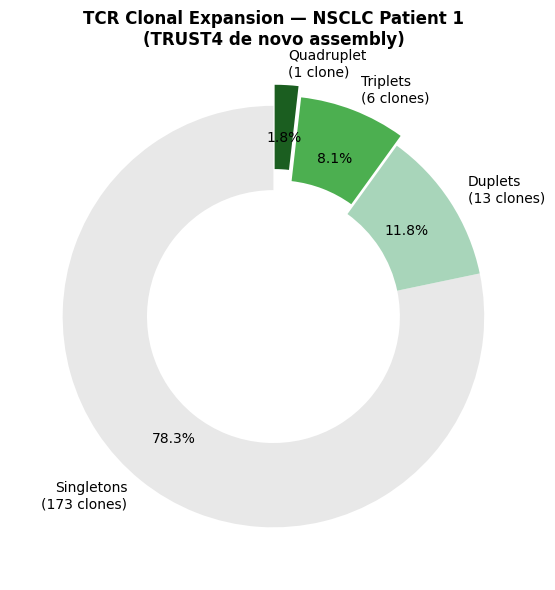

In [34]:
import matplotlib.pyplot as plt

labels = ['Singletons\n(173 clones)', 'Duplets\n(13 clones)',
          'Triplets\n(6 clones)', 'Quadruplet\n(1 clone)']
sizes = [173, 13*2, 6*3, 1*4]  # number of CELLS
colors = ['#E8E8E8', '#A8D5BA', '#4CAF50', '#1B5E20']
explode = (0, 0, 0.05, 0.1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='%1.1f%%', startangle=90, pctdistance=0.75,
       wedgeprops=dict(width=0.4))  # donut
ax.set_title('TCR Clonal Expansion — NSCLC Patient 1\n(TRUST4 de novo assembly)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('panel_a_clonal_expansion.pdf', dpi=300)

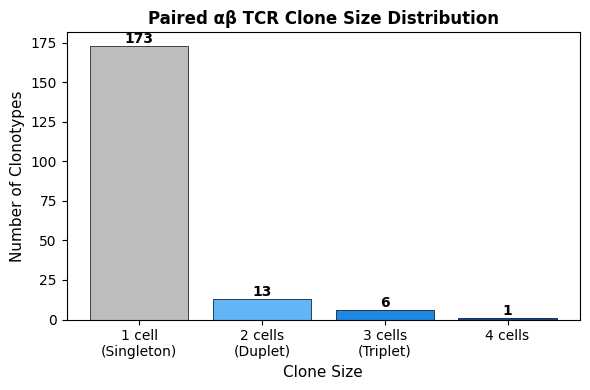

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

clone_dist = pd.DataFrame({
    'Clone Size': ['1 cell\n(Singleton)', '2 cells\n(Duplet)',
                   '3 cells\n(Triplet)', '4 cells'],
    'Number of Clonotypes': [173, 13, 6, 1]
})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(clone_dist['Clone Size'], clone_dist['Number of Clonotypes'],
              color=['#BDBDBD', '#64B5F6', '#1E88E5', '#0D47A1'],
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Number of Clonotypes', fontsize=11)
ax.set_title('Paired αβ TCR Clone Size Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Clone Size', fontsize=11)

# Add value labels on bars
for bar, val in zip(bars, clone_dist['Number of Clonotypes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('panel_b_clone_distribution.pdf', dpi=300)

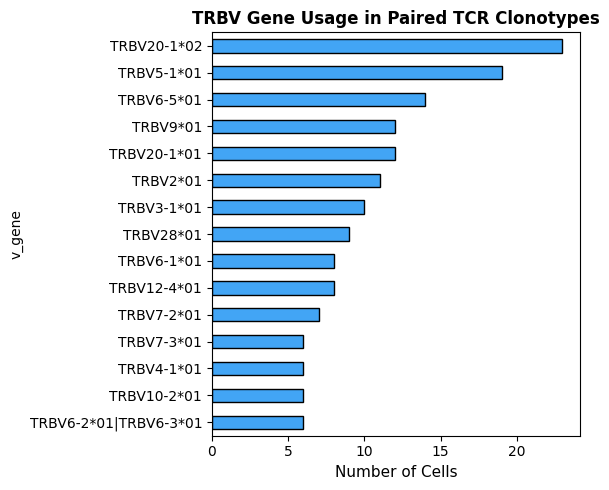

In [36]:
# From your top 20 clonotypes, count TRBV usage
trbv_usage = trust_paired[trust_paired['chain'] == 'TRB']['v_gene'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(6, 5))
trbv_usage.sort_values().plot(kind='barh', ax=ax, color='#42A5F5', edgecolor='black')
ax.set_xlabel('Number of Cells', fontsize=11)
ax.set_title('TRBV Gene Usage in Paired TCR Clonotypes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('panel_c_trbv_usage.pdf', dpi=300)

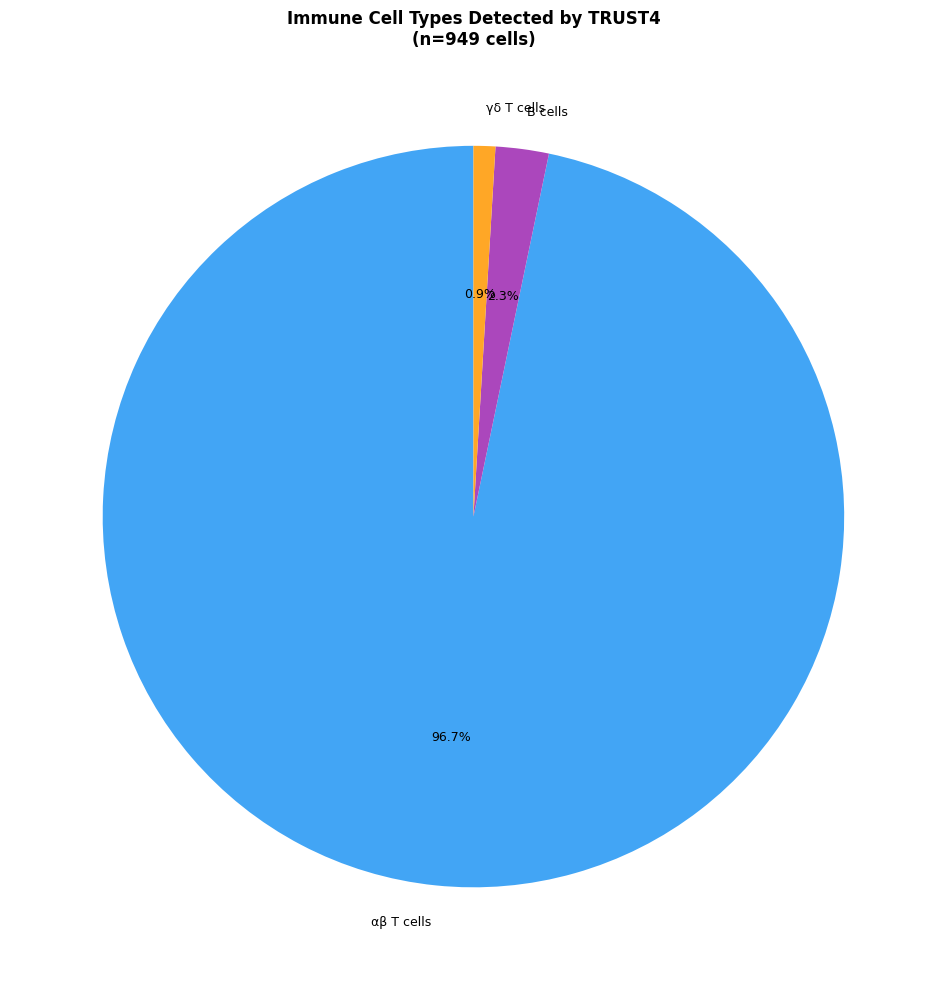

In [39]:
cell_types = pd.DataFrame({
    'Cell Type': ['αβ T cells', 'B cells', 'γδ T cells'],
    'Count': [918, 22, 9]
})

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(cell_types['Count'], labels=cell_types['Cell Type'],
       autopct='%1.1f%%', colors=['#42A5F5', '#AB47BC', '#FFA726'],
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Immune Cell Types Detected by TRUST4\n(n=949 cells)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('panel_d_cell_types.pdf', dpi=300)

```tex
scRNA-seq FASTQ (SRR13342054)
         │
    TRUST4 de novo assembly
         │
    949 cells with TCR/BCR
         │
    Filter: paired TRA+TRB
         │
    193 unique paired clonotypes
         │
    ┌─────────┴─────────┐
    │                   │
 173 singletons    20 expanded
   (unique TCR)    (shared TCR)
                        │
              1× size=4, 6× size=3,
                  13× size=2

# 🥼 Summary & Key Takeaways


```tex
1. Standard scRNA-seq misses TCR/BCR → V(D)J recombined sequences can't be
2. TRUST4 recovers TCR/BCR from existing GEX data → De novo assembly reconstructs CDR3 sequences at single-cell level, at no additional cost
3. Integration with Scirpy enables joint analysis → Each cell gets both gene expression AND TCR identity
4. Clonal expansion reveals antigen reactivity → Expanded clonotypes = antigen-driven T cells
```

## References
Song, L. et al. TRUST4: immune repertoire reconstruction from bulk and single-cell RNA-seq data. Nat Methods (2021). https://doi.org/10.1038/s41592-021-01142-2

Sturm, G. et al. Scirpy: a Scanpy extension for analyzing single-cell T-cell receptor-sequencing data. Bioinformatics (2020).

Kim, H.R. et al. Integrative single-cell RNA and T-cell receptor analyses... GEO: GSE164146 (2023).

Liu, Y. et al. RIMA: RNA-seq Immune Analysis tutorial. https://liulab-dfci.github.io/RIMA/

---
🧬 *BMGLab Bioinformatics Workshop - 02.07.2026 - İzmir*